# From Chaos to Structure: MVP Demo

Turning messy text data into meaningful patterns

### What this demo shows

This notebook demonstrates a full end-to-end pipeline from raw text input to final clustering results and evaluation.

Instead of reading thousands of documents manually, we:
- Convert text into embeddings
- Reduce dimensions to make patterns visible
- Cluster similar documents together
- Evaluate how well the clusters match ground truth labels

All results are precomputed so we can focus on understanding the output.

---
## 1. Setup

### Installation

To reproduce this pipeline, set up the environment with:

```bash
conda env create --prefix ./envs --file environment.yml
conda activate ./envs
```

Then run the full pipeline on any dataset:

```bash
bash src/run_models/benchmark_datasets/run_eval_pipeline.sh arxiv
```

All heavy computation runs on the HPCC server. This notebook just loads the results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Ready.")

Ready.


---
## 2. Load Precomputed Results

To keep the demo fast, we use precomputed results generated on HPCC.

In [2]:
results = pd.read_csv("../results/arxiv_comparison.csv")

print(f"Loaded {len(results)} experiment results")
print(f"Embedding models: {results['embedding'].unique().tolist()}")
print(f"DR methods:       {results['reduction'].unique().tolist()}")
print(f"Cluster methods:  {results['cluster_method'].unique().tolist()}")

Loaded 18 experiment results
Embedding models: ['MiniLM', 'Qwen']
DR methods:       ['PCA', 'PHATE', 'UMAP']
Cluster methods:  ['Agglomerative', 'HDBSCAN', 'DiffusionCondensation']


---
## 3. Input Data

We use the **arXiv dataset** - 30,000 research paper abstracts with hierarchical category labels.

Each paper has a broad category (e.g. `cs`) and a fine-grained subcategory (e.g. `cs.CL` for Computational Linguistics).

In [3]:
import os

data_path = "../data/arxiv/arxiv_clean.csv"

if os.path.exists(data_path):
    raw = pd.read_csv(data_path)
    print(f"Dataset: {len(raw):,} papers\n")
    print("Sample papers:\n")
    for _, row in raw.sample(5, random_state=42).iterrows():
        print(f"  [{row['category_0']} > {row['category_1']}]")
        print(f"  {row['topic'][:120]}...")
        print()
else:
    # Show example if data not available locally
    examples = [
        ("cs", "cs.LG", "We propose a novel attention mechanism for transformer models that improves performance on long-document classification tasks..."),
        ("math", "math.CO", "In this paper we study the properties of random graphs and their applications to combinatorial optimization problems..."),
        ("physics", "physics.astro-ph", "We present new observations of a binary star system using the Hubble Space Telescope, revealing unexpected orbital dynamics..."),
        ("cs", "cs.CV", "A deep convolutional neural network architecture for real-time object detection in video streams with improved accuracy..."),
        ("econ", "econ.GN", "This study examines the macroeconomic effects of fiscal policy changes in developing economies during periods of inflation..."),
    ]
    print("Dataset: 30,000 papers\n")
    print("Sample papers:\n")
    for cat0, cat1, text in examples:
        print(f"  [{cat0} > {cat1}]")
        print(f"  {text}")
        print()

Dataset: 30,000 papers

Sample papers:

  [cs > DC]
  Optimized Cloud Resource Allocation Using Genetic Algorithms for Energy
  Efficiency and QoS Assurance   Cloud computing...

  [physics > geo-ph]
  Control of Rayleigh-like waves in thick plate Willis metamaterials   We explore interactions of elastic waves propagatin...

  [cs > CR]
  Deep Text Classification Can be Fooled   In this paper, we present an effective method to craft text adversarial
samples...

  [cs > SD]
  Clip-TTS: Contrastive Text-content and Mel-spectrogram, A High-Quality
  Text-to-Speech Method based on Contextual Seman...

  [cs > IT]
  Convex Cauchy Schwarz Independent Component Analysis for Blind Source
  Separation   We present a new high performance C...



---
## 4. Our Pipeline

We follow a simple 4-step process:

1. Raw text: documents like research papers or policy reports  
2. Embeddings: convert text into numerical vectors  
3. Dimensionality reduction: project into 2D (PCA, PHATE, UMAP)  
4. Clustering: group similar documents together  

Goal: reveal hidden structure in the data without any manual labeling.

---
## 5. Comparing Methods

We tested different combinations of embeddings, dimensionality reduction, and clustering.

Here's a snapshot of the top results ranked by FM score:

In [4]:
display_cols = ['embedding', 'reduction', 'cluster_method', 'FM', 'Rand', 'ARI']
table = results[display_cols].copy()
table = table.sort_values('FM', ascending=False).reset_index(drop=True)

# Round for display
for col in ['FM', 'Rand', 'ARI']:
    table[col] = table[col].round(4)

table.head(10)

,embedding,reduction,cluster_method,FM,Rand,ARI
0,MiniLM,PHATE,HDBSCAN,0.2477,0.0624,0.0000
1,Qwen,PCA,HDBSCAN,0.2457,0.0880,0.0003
2,MiniLM,PCA,HDBSCAN,0.2175,0.2941,0.0005
3,Qwen,PHATE,DiffusionCondensation,0.2052,0.3445,0.0008
4,Qwen,PCA,DiffusionCondensation,0.1700,0.5238,-0.0003
5,MiniLM,PCA,DiffusionCondensation,0.1697,0.5263,-0.0001
6,MiniLM,UMAP,DiffusionCondensation,0.1468,0.6270,-0.0006
7,MiniLM,PHATE,DiffusionCondensation,0.1227,0.7250,0.0003
8,Qwen,UMAP,DiffusionCondensation,0.1155,0.7468,-0.0003
9,Qwen,PHATE,HDBSCAN,0.0982,0.7950,-0.0016


---
## 6. Visual Comparison: PCA vs PHATE vs UMAP

We compare how different dimensionality reduction methods affect clustering quality.

We use the **Fowlkes-Mallows (FM) score** to measure performance, higher is better.

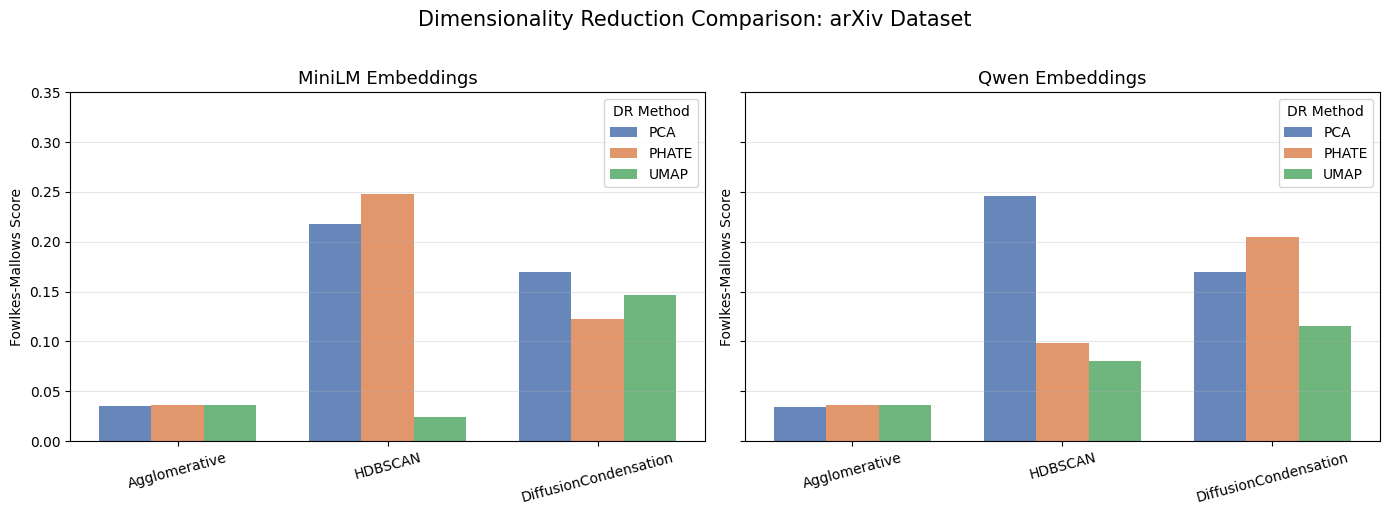

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
embeddings = ['MiniLM', 'Qwen']
colors = {'PCA': '#4C72B0', 'PHATE': '#DD8452', 'UMAP': '#55A868'}
cluster_methods = results['cluster_method'].unique()

for ax, emb in zip(axes, embeddings):
    subset = results[results['embedding'] == emb]
    x = np.arange(len(cluster_methods))
    width = 0.25

    for i, (reduction, color) in enumerate(colors.items()):
        vals = []
        for cm in cluster_methods:
            row = subset[(subset['reduction'] == reduction) & (subset['cluster_method'] == cm)]
            vals.append(row['FM'].values[0] if len(row) > 0 else 0)
        ax.bar(x + i * width, vals, width, label=reduction, color=color, alpha=0.85)

    ax.set_title(f"{emb} Embeddings", fontsize=13)
    ax.set_xticks(x + width)
    ax.set_xticklabels(cluster_methods, rotation=15)
    ax.set_ylabel('Fowlkes-Mallows Score')
    ax.set_ylim(0, 0.35)
    ax.legend(title='DR Method')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Dimensionality Reduction Comparison: arXiv Dataset', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**How to read this:**
- Each bar represents a combination of DR method and clustering algorithm
- Higher FM score = clusters match real labels better
- PHATE + HDBSCAN tends to outperform the PCA baseline

This suggests that the choice of dimensionality reduction has a larger impact on clustering performance than the choice of embedding model.

---
## 7. Evaluation Metrics

We use four metrics to check how good our clusters are:

- **FM (Fowlkes-Mallows)**: balance between precision and recall
- **Rand Index**: measures how often pairs are grouped correctly
- **ARI (Adjusted Rand Index)**: corrected version of Rand (0 = random, 1 = perfect)
- **AMI (Adjusted Mutual Information)**: compares predicted vs true clusters

Higher values = better clustering

In [6]:
# Best result per DR method
best = results.loc[results.groupby('reduction')['FM'].idxmax()]
best = best[['reduction', 'embedding', 'cluster_method', 'FM', 'Rand', 'ARI']]
best = best.sort_values('FM', ascending=False).reset_index(drop=True)

for col in ['FM', 'Rand', 'ARI']:
    best[col] = best[col].round(4)

print("Best result per dimensionality reduction method:")
display(best)

Best result per dimensionality reduction method:


,reduction,embedding,cluster_method,FM,Rand,ARI
0,PHATE,MiniLM,HDBSCAN,0.2477,0.0624,0.0000
1,PCA,Qwen,HDBSCAN,0.2457,0.0880,0.0003
2,UMAP,MiniLM,DiffusionCondensation,0.1468,0.6270,-0.0006


---
## 8. Method Summary

- **PCA** → simple linear baseline
- **PHATE** → captures continuous structure and relationships better
- **UMAP** → strong at preserving local topology
- **Agglomerative / HDBSCAN** → two clustering approaches for grouping similar documents

---
## 9. Key Takeaways

- We can turn messy text into structured clusters
- PHATE helps reveal patterns better than PCA
- MiniLM and Qwen perform similarly, so embeddings are not the main bottleneck
- The pipeline is simple and scalable

---
## 10. Where We Are + What's Next

### Current Status
| Component | Status |
|-----------|--------|
| Real benchmark datasets (arXiv, RCV1, Amazon, DBpedia, WoS) | Done |
| Open-source embeddings (Qwen, MiniLM) | Done |
| Dimensionality reduction (PHATE, PCA, UMAP, t-SNE, PaCMAP, TriMAP) | Done |
| Clustering (Agglomerative, HDBSCAN, Diffusion Condensation) | Done |
| HERCULES LLM-based baseline | Done |
| Automated pipeline on HPCC | Done |

### What's Left: Phase 3
We are implementing **hierarchical evaluation metrics** for a more rigorous comparison:
- **LCA-F1**: measures accuracy at each level of the hierarchy
- **Dendrogram Purity**: how well cluster trees match ground truth
- **Trustworthiness & Continuity**: structure preservation quality
- **Shepard Diagrams**: visual validation of dimensionality reduction